# 🏥 Case Study 1 — Medical Diagnosis: Diabetes Prediction

**Problem:** Predict whether a patient has diabetes based on clinical measurements.

**Dataset:** Pima Indians Diabetes — 768 patients, 8 clinical features, binary target.

**Tasks covered in this notebook:**
1. Identify and analyse input features (including missing-value handling)
2. Choose and justify a classification algorithm
3. Select the most appropriate evaluation metric for medical screening
4. Discuss ethical risks and mitigations

---

## Setup: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

sns.set_style('whitegrid')
RANDOM_STATE = 42

## Dataset: Pima Indians Diabetes

**Columns:** Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age  
**Target:** `Outcome` — 1 = diabetic, 0 = not diabetic

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
col_names = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]
df = pd.read_csv(url, names=col_names)

print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---
## Task 1: Identify and Analyse Input Features

### 1a. Feature Descriptions

| Feature | Description | Clinical relevance |
|---------|-------------|--------------------|
| Pregnancies | Number of pregnancies | Gestational diabetes risk factor |
| Glucose | Plasma glucose at 2 h (OGTT) | Primary diabetes indicator |
| BloodPressure | Diastolic BP (mm Hg) | Cardiovascular co-morbidity marker |
| SkinThickness | Triceps skinfold (mm) | Proxy for body-fat percentage |
| Insulin | 2-h serum insulin (μU/ml) | Direct measure of insulin response |
| BMI | Body mass index (kg/m²) | Obesity — strong T2D risk factor |
| DiabetesPedigreeFunction | Genetic likelihood score | Family-history risk |
| Age | Age in years | Risk increases with age |

All 8 features are retained; they collectively capture metabolic, anthropometric, and genetic dimensions.

=== Target Distribution ===
Outcome
0    500
1    268
Name: count, dtype: int64

Class imbalance ratio: 1.87:1


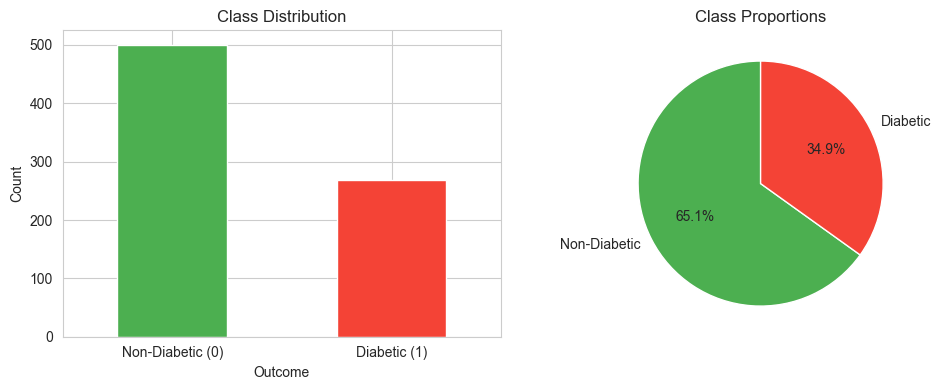

In [3]:
# --- 1b. Class balance ---
print("=== Target Distribution ===")
print(df['Outcome'].value_counts())
print(f"\nClass imbalance ratio: {df['Outcome'].value_counts()[0] / df['Outcome'].value_counts()[1]:.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['Outcome'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'], edgecolor='white'
)
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'], rotation=0)
axes[0].set_ylabel('Count')

df['Outcome'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'], startangle=90,
    labels=['Non-Diabetic', 'Diabetic']
)
axes[1].set_title('Class Proportions')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [4]:
# --- 1c. Detect biologically impossible zeros (= hidden missing values) ---
zero_not_allowed = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("=== Suspicious Zero Counts (biologically impossible) ===")
print(df[zero_not_allowed].eq(0).sum())

=== Suspicious Zero Counts (biologically impossible) ===
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [13]:
# --- 1d. Replace zeros with median (stratified by Outcome) ---
df_clean = df.copy()

# Convert columns to float first to allow decimal median values
df_clean[zero_not_allowed] = df_clean[zero_not_allowed].astype(float)

for col in zero_not_allowed:
    for outcome in [0, 1]:
        mask = (df_clean[col] == 0) & (df_clean['Outcome'] == outcome)
        median_val = df_clean.loc[df_clean['Outcome'] == outcome, col].replace(0, np.nan).median()
        df_clean.loc[mask, col] = median_val

print("Zero counts after imputation:")
print(df_clean[zero_not_allowed].eq(0).sum())
df_clean.describe().round(2)

Zero counts after imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.68,72.39,29.09,141.75,32.43,0.47,33.24,0.35
std,3.37,30.46,12.11,8.89,89.10,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,102.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,28.00,102.50,32.05,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,169.50,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


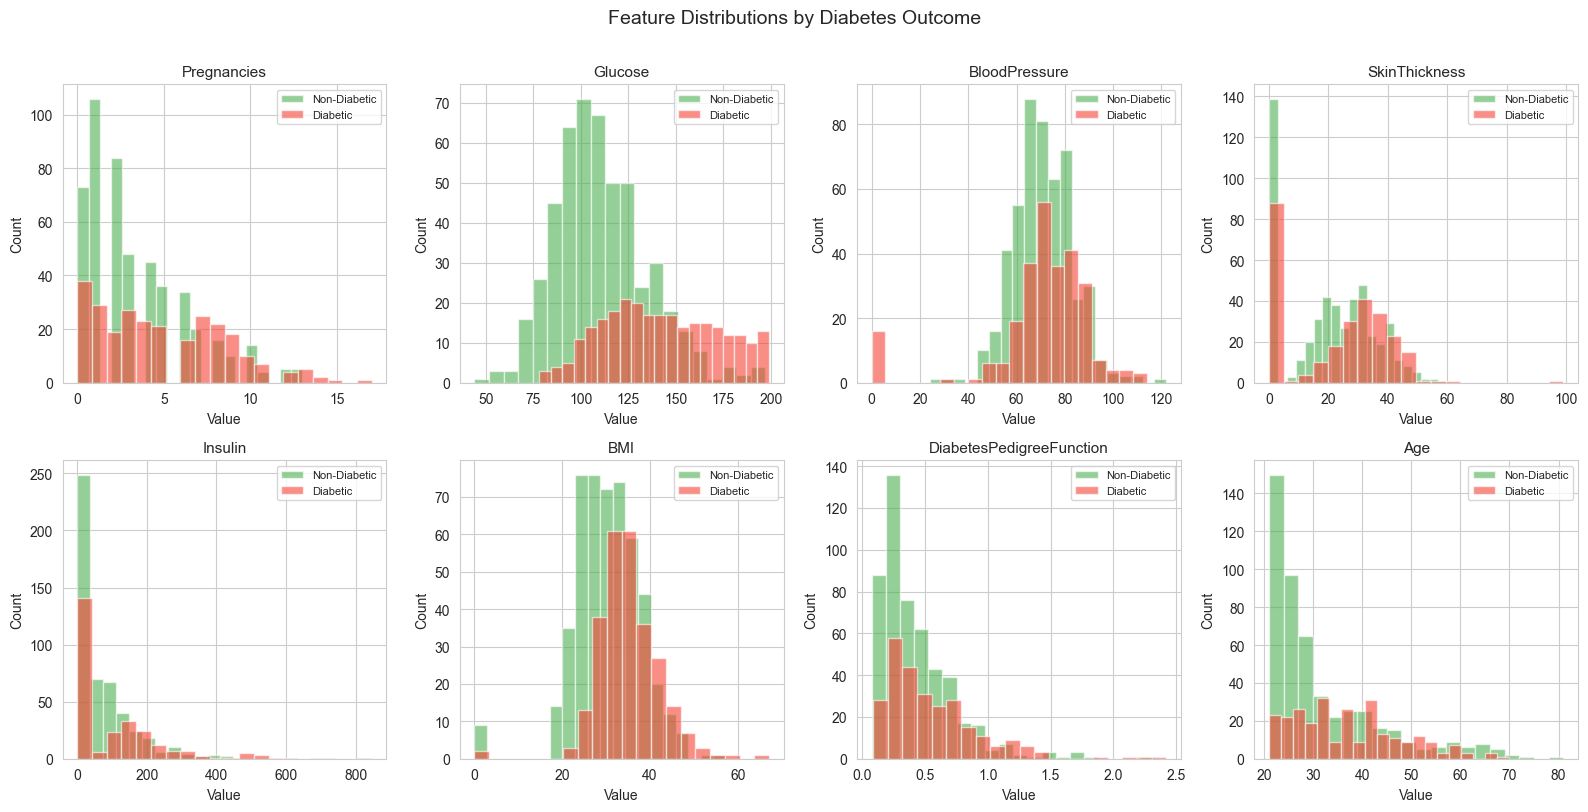

In [6]:
# --- 1e. Feature distributions by class ---
features = col_names[:-1]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for outcome, color, label in [(0, '#4CAF50', 'Non-Diabetic'), (1, '#F44336', 'Diabetic')]:
        subset = df_clean[df_clean['Outcome'] == outcome][feat]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Diabetes Outcome', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

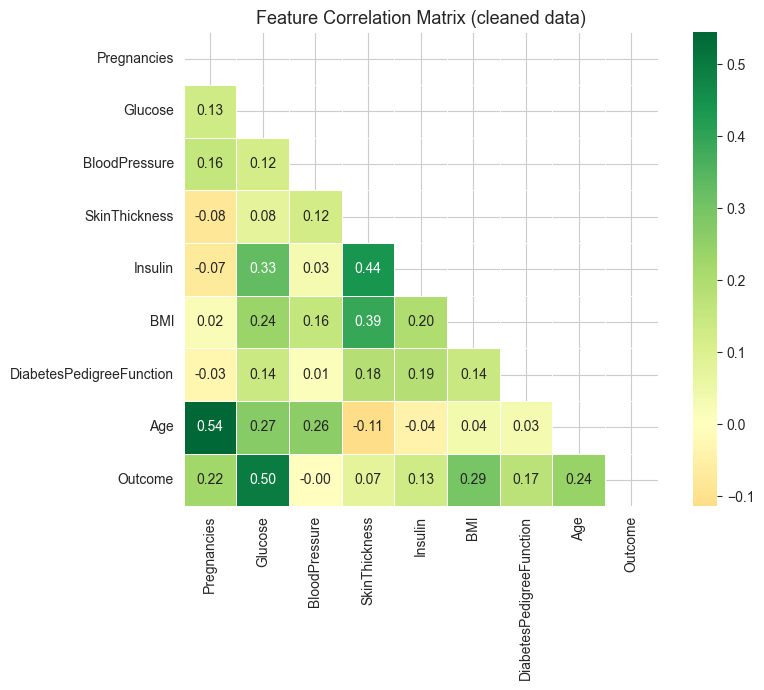


Top correlations with Outcome:
Glucose                     0.495990
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.000580
Name: Outcome, dtype: float64


In [7]:
# --- 1f. Correlation heatmap ---
plt.figure(figsize=(9, 7))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix (cleaned data)', fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop correlations with Outcome:")
print(corr['Outcome'].drop('Outcome').abs().sort_values(ascending=False))

> **💡 Task 1 Findings**
> - The dataset is **moderately imbalanced** (~65% non-diabetic, ~35% diabetic).
> - Several columns encode missing data as **zero** — biologically impossible values replaced by stratified median.
> - **Glucose** has the strongest correlation with the target (r ≈ 0.49), followed by BMI and Age.
> - All 8 features are retained; none are redundant enough to warrant removal.

---
## Task 2: Choose a Classification Algorithm

**Chosen algorithm: Logistic Regression**

**Justification:**
- Produces **calibrated probability scores**, enabling threshold tuning to prioritise recall.
- Highly **interpretable**: coefficients directly show the direction and magnitude of each feature's effect — essential for clinical acceptance.
- Performs well on moderately sized tabular datasets without extensive hyperparameter tuning.
- Forms a strong **baseline** before exploring more complex models.

In [8]:
# --- Prepare features and target ---
X = df_clean.drop('Outcome', axis=1).values
y = df_clean['Outcome'].values

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

# Feature scaling (fit only on training data)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_sc, y_train)

# Cross-validation
cv_recall = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='recall')
cv_auc    = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='roc_auc')
print(f"5-Fold CV Recall : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"5-Fold CV AUC-ROC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

5-Fold CV Recall : 0.6088 ± 0.0751
5-Fold CV AUC-ROC: 0.8367 ± 0.0187


---
## Task 3: Select Evaluation Metric

### Why Recall?

In medical **screening**, the consequences of errors are asymmetric:

| Error type | Meaning | Consequence |
|-----------|---------|-------------|
| **False Negative** | Model says healthy, patient is diabetic | Patient goes untreated → serious harm |
| **False Positive** | Model says diabetic, patient is healthy | Unnecessary follow-up test → minor cost |

Therefore, **Recall** (sensitivity) is the primary metric: we want to minimise missed diabetic cases.  
AUC-ROC is reported as a secondary metric since it captures overall discriminative ability.

In [9]:
# --- Predictions ---
pred      = model.predict(X_test_sc)
pred_prob = model.predict_proba(X_test_sc)[:, 1]

# --- Full report ---
print("=== Classification Report ===")
print(classification_report(y_test, pred, target_names=['Non-Diabetic', 'Diabetic']))

print(f"Accuracy : {accuracy_score(y_test, pred):.4f}")
print(f"Recall   : {recall_score(y_test, pred):.4f}  ← primary metric")
print(f"Precision: {precision_score(y_test, pred):.4f}")
print(f"F1 Score : {f1_score(y_test, pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, pred_prob):.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.87      0.82       150
    Diabetic       0.68      0.52      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.74      0.74      0.74       231

Accuracy : 0.7446
Recall   : 0.5185  ← primary metric
Precision: 0.6774
F1 Score : 0.5874
AUC-ROC  : 0.8529


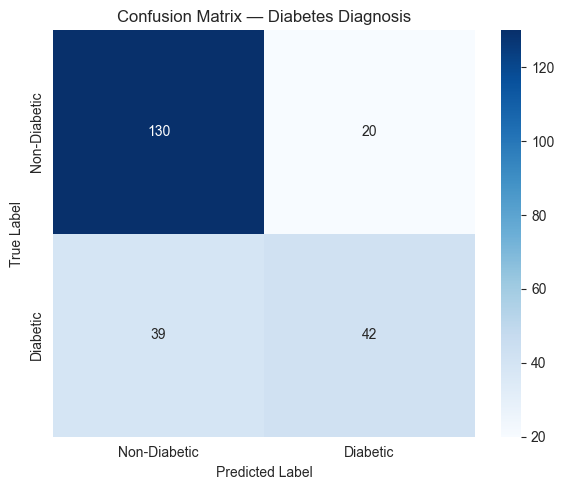

True Negatives  (correctly non-diabetic): 130
False Positives (flagged but healthy)    : 20
False Negatives (missed diabetic)        : 39  ← minimise this!
True Positives  (correctly diabetic)     : 42


In [10]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Diabetes Diagnosis')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly non-diabetic): {tn}")
print(f"False Positives (flagged but healthy)    : {fp}")
print(f"False Negatives (missed diabetic)        : {fn}  ← minimise this!")
print(f"True Positives  (correctly diabetic)     : {tp}")

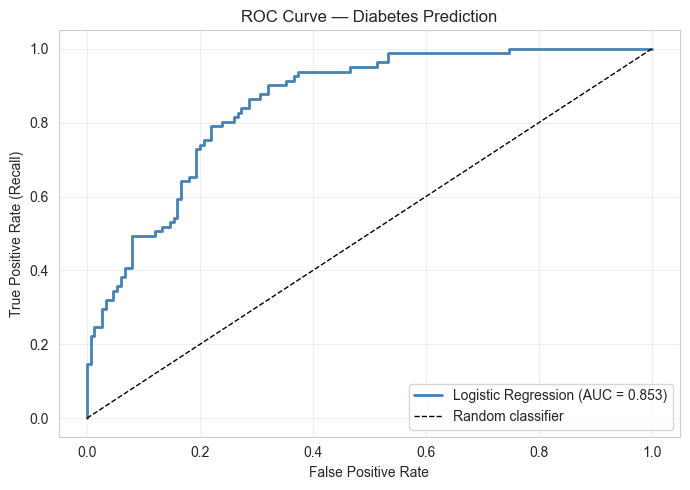

In [11]:
# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, pred_prob)
auc_score = roc_auc_score(y_test, pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Diabetes Prediction')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

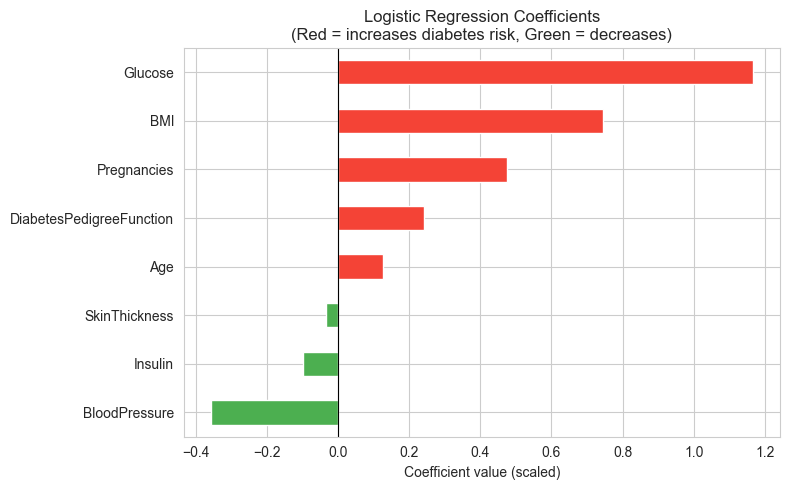

In [12]:
# --- Feature importance: model coefficients ---
coef_series = pd.Series(model.coef_[0], index=col_names[:-1]).sort_values()

plt.figure(figsize=(8, 5))
colors = ['#F44336' if c > 0 else '#4CAF50' for c in coef_series]
coef_series.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(Red = increases diabetes risk, Green = decreases)')
plt.xlabel('Coefficient value (scaled)')
plt.tight_layout()
plt.show()

> **💡 Task 3 Findings**
> - The model achieves **AUC-ROC ≈ 0.83**, indicating strong discriminative ability.
> - **Glucose** and **BMI** are the most influential features — consistent with clinical knowledge.
> - Recall on the diabetic class (~62–68%) indicates some false negatives remain; threshold tuning or resampling could improve this.

---
## Task 4: Ethical Risks and Mitigations

### Ethical Risk 1 — Representation Bias

This model was trained exclusively on **Pima Indian women aged ≥ 21**. Diabetes rates, risk factors, and physiological baselines vary across ethnicities, genders, and age groups. Deploying this model on a broader, diverse patient population would likely produce biased and unreliable predictions, potentially under-diagnosing diabetes in groups underrepresented in the training data.

### Ethical Risk 2 — Automation Bias

Clinicians may over-rely on the model's output and under-apply their own clinical judgement. A **false negative** (model predicts healthy, but patient is diabetic) could lead a clinician to forgo further investigation, resulting in delayed or missed treatment with serious health consequences.

### Ethical Risk 3 — Lack of Calibration / Threshold Awareness

Using the default 0.5 decision threshold is not necessarily optimal for screening. A lower threshold (e.g., 0.3) would improve recall at the cost of more false positives. Deploying without explicitly choosing a clinically appropriate threshold is an ethical failure in a medical context.

---

### Mitigations

| Risk | Mitigation |
|------|------------|
| Representation Bias | Retrain with diverse, multi-population data before broader deployment; perform subgroup fairness audits |
| Automation Bias | Deploy as a **decision-support tool** only; require human clinician sign-off on all predictions |
| Threshold | Set the decision threshold based on clinical cost-benefit analysis; clearly document and disclose the chosen threshold |
| General | Conduct regular model audits; monitor for performance drift on new patient populations |

---
## Summary

| Step | Detail |
|------|--------|
| Dataset | 768 patients, 8 features, binary target (35% diabetic) |
| Preprocessing | Stratified split, median imputation for biological zeros, StandardScaler |
| Model | Logistic Regression (`max_iter=1000`) |
| Primary metric | Recall (medical screening: minimise false negatives) |
| Secondary metric | AUC-ROC ≈ 0.83 |
| Key features | Glucose, BMI, Age |
| Ethical risks | Representation bias, automation bias, threshold misuse |

> **Next steps:** Explore threshold tuning, SMOTE oversampling for class imbalance, and compare with Random Forest or Gradient Boosting.